In [1]:
from pathlib import Path
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import scipy.sparse as sp

import scanpy as sc
import anndata as ad
import cellxgene_census

from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)

import joblib

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

sc.settings.verbosity = 2
sc.settings.set_figure_params(dpi=100, facecolor="white")

DATA_DIR = Path("../data")
RESULTS_DIR = Path("../results")
FIGURES_DIR = Path("../figures")
MODEL_DIR = Path("../models")

for d in [DATA_DIR, RESULTS_DIR, FIGURES_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

In [3]:
import torch
import scgpt

from scgpt.tokenizer import GeneVocab

print("PyTorch:", torch.__version__)
print("scGPT:", scgpt.__version__ if hasattr(scgpt, "__version__") else scgpt.__file__)

if torch.cuda.is_available():
    DEVICE = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

print("Device:", DEVICE)

/Users/skamano/miniconda3/envs/scgpt-project/lib/python3.10/site-packages/scgpt/model/model.py:21: UserWarning: flash_attn is not installed
  warnings.warn("flash_attn is not installed")
/Users/skamano/miniconda3/envs/scgpt-project/lib/python3.10/site-packages/scgpt/model/multiomic_model.py:19: UserWarning: flash_attn is not installed
  warnings.warn("flash_attn is not installed")
/Users/skamano/miniconda3/envs/scgpt-project/lib/python3.10/site-packages/torchtext/vocab/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
/Users/skamano/miniconda3/envs/scgpt-project/lib/python3.10/site-packages/torchtext/utils.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /

PyTorch: 2.3.0
scGPT: 0.2.4
Device: mps


In [4]:
#Load pretrained scGPT model checkpoint
SCGPT_MODEL_DIR = MODEL_DIR / "scGPT_human"

vocab_file = SCGPT_MODEL_DIR / "vocab.json"
config_file = SCGPT_MODEL_DIR / "args.json"
model_file = SCGPT_MODEL_DIR / "best_model.pt"

for f in [vocab_file, config_file, model_file]:
    assert f.exists(), f"Missing: {f}"

vocab = GeneVocab.from_file(vocab_file)

with open(config_file) as f:
    model_config = json.load(f)

state_dict = torch.load(
    model_file,
    map_location="cpu",
    weights_only=False,
)

print("Vocabulary size:", len(vocab))
print("Checkpoint tensors:", len(state_dict))

print("\nModel configuration:")
for key in [
    "embsize",
    "nheads",
    "d_hid",
    "nlayers",
    "n_layers_cls",
    "dropout",
]:
    print(key, ":", model_config.get(key))

Vocabulary size: 60697
Checkpoint tensors: 163

Model configuration:
embsize : 512
nheads : 8
d_hid : 512
nlayers : 12
n_layers_cls : 3
dropout : 0.2


In [5]:
#Download PBMC dataset
DATASET_ID = "fa8605cf-f27e-44af-ac2a-476bee4410d3"

obs_columns = [
    "dataset_id",
    "donor_id",
    "cell_type",
    "disease",
    "assay",
    "tissue",
    "tissue_general",
    "is_primary_data",
]

var_columns = [
    "feature_id",
    "feature_name",
]

with cellxgene_census.open_soma() as census:
    adata = cellxgene_census.get_anndata(
        census=census,
        organism="Homo sapiens",
        measurement_name="RNA",
        X_name="raw",
        obs_value_filter=(
            f"dataset_id == '{DATASET_ID}' "
            "and is_primary_data == True"
        ),
        obs_column_names=obs_columns,
        var_column_names=var_columns,
    )

adata

The "stable" release is currently 2025-11-08. Specify 'census_version="2025-11-08"' in future calls to open_soma() to ensure data consistency.
/Users/skamano/miniconda3/envs/scgpt-project/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/skamano/miniconda3/envs/scgpt-project/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


AnnData object with n_obs × n_vars = 59506 × 61497
    obs: 'dataset_id', 'donor_id', 'cell_type', 'disease', 'assay', 'tissue', 'tissue_general', 'is_primary_data'
    var: 'feature_id', 'feature_name'

In [6]:
#Removing empty values
for col in [
    "donor_id",
    "cell_type",
    "disease",
    "assay",
    "tissue",
    "tissue_general",
]:
    if hasattr(adata.obs[col], "cat"):
        adata.obs[col] = adata.obs[col].cat.remove_unused_categories()

In [7]:
#Set gene names
adata.var["gene_name"] = adata.var["feature_name"].astype(str)

# Use Ensembl IDs as unique AnnData indices
adata.var_names = adata.var["feature_id"].astype(str)
adata.var_names_make_unique()

print(adata.var[["gene_name"]].head())

                       gene_name
feature_id                      
ENSG00000237491        LINC01409
ENSG00000188976            NOC2L
ENSG00000187642            PERM1
ENSG00000272512  ENSG00000272512
ENSG00000188290             HES4


In [8]:
#Check and remove cells with unused donor labels
adata.obs["donor_id"] = adata.obs["donor_id"].astype(str)
adata.obs["cell_type"] = adata.obs["cell_type"].astype(str)

bad_donors = {
    "",
    "unknown",
    "Unknown",
    "nan",
    "NA",
    "N/A",
}

valid_donor = ~adata.obs["donor_id"].isin(bad_donors)

print("Dropping cells without usable donor labels:",
      (~valid_donor).sum())

adata = adata[valid_donor].copy()

Dropping cells without usable donor labels: 0


In [9]:
adata.var["mt"] = adata.var["gene_name"].str.upper().str.startswith("MT-")

sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt"],
    percent_top=None,
    log1p=False,
    inplace=True,
)

adata.obs[
    [
        "total_counts",
        "n_genes_by_counts",
        "pct_counts_mt",
    ]
].describe()

,total_counts,n_genes_by_counts,pct_counts_mt
count,59506.000000,59506.000000,59506.000000
mean,4015.037842,1358.098763,2.896502
std,3101.187988,617.778449,2.544933
min,625.000000,498.000000,0.010900
25%,1985.000000,906.000000,1.196745
50%,3266.000000,1238.000000,2.000413
75%,4953.000000,1646.000000,3.712244
max,58194.000000,6571.000000,28.578918


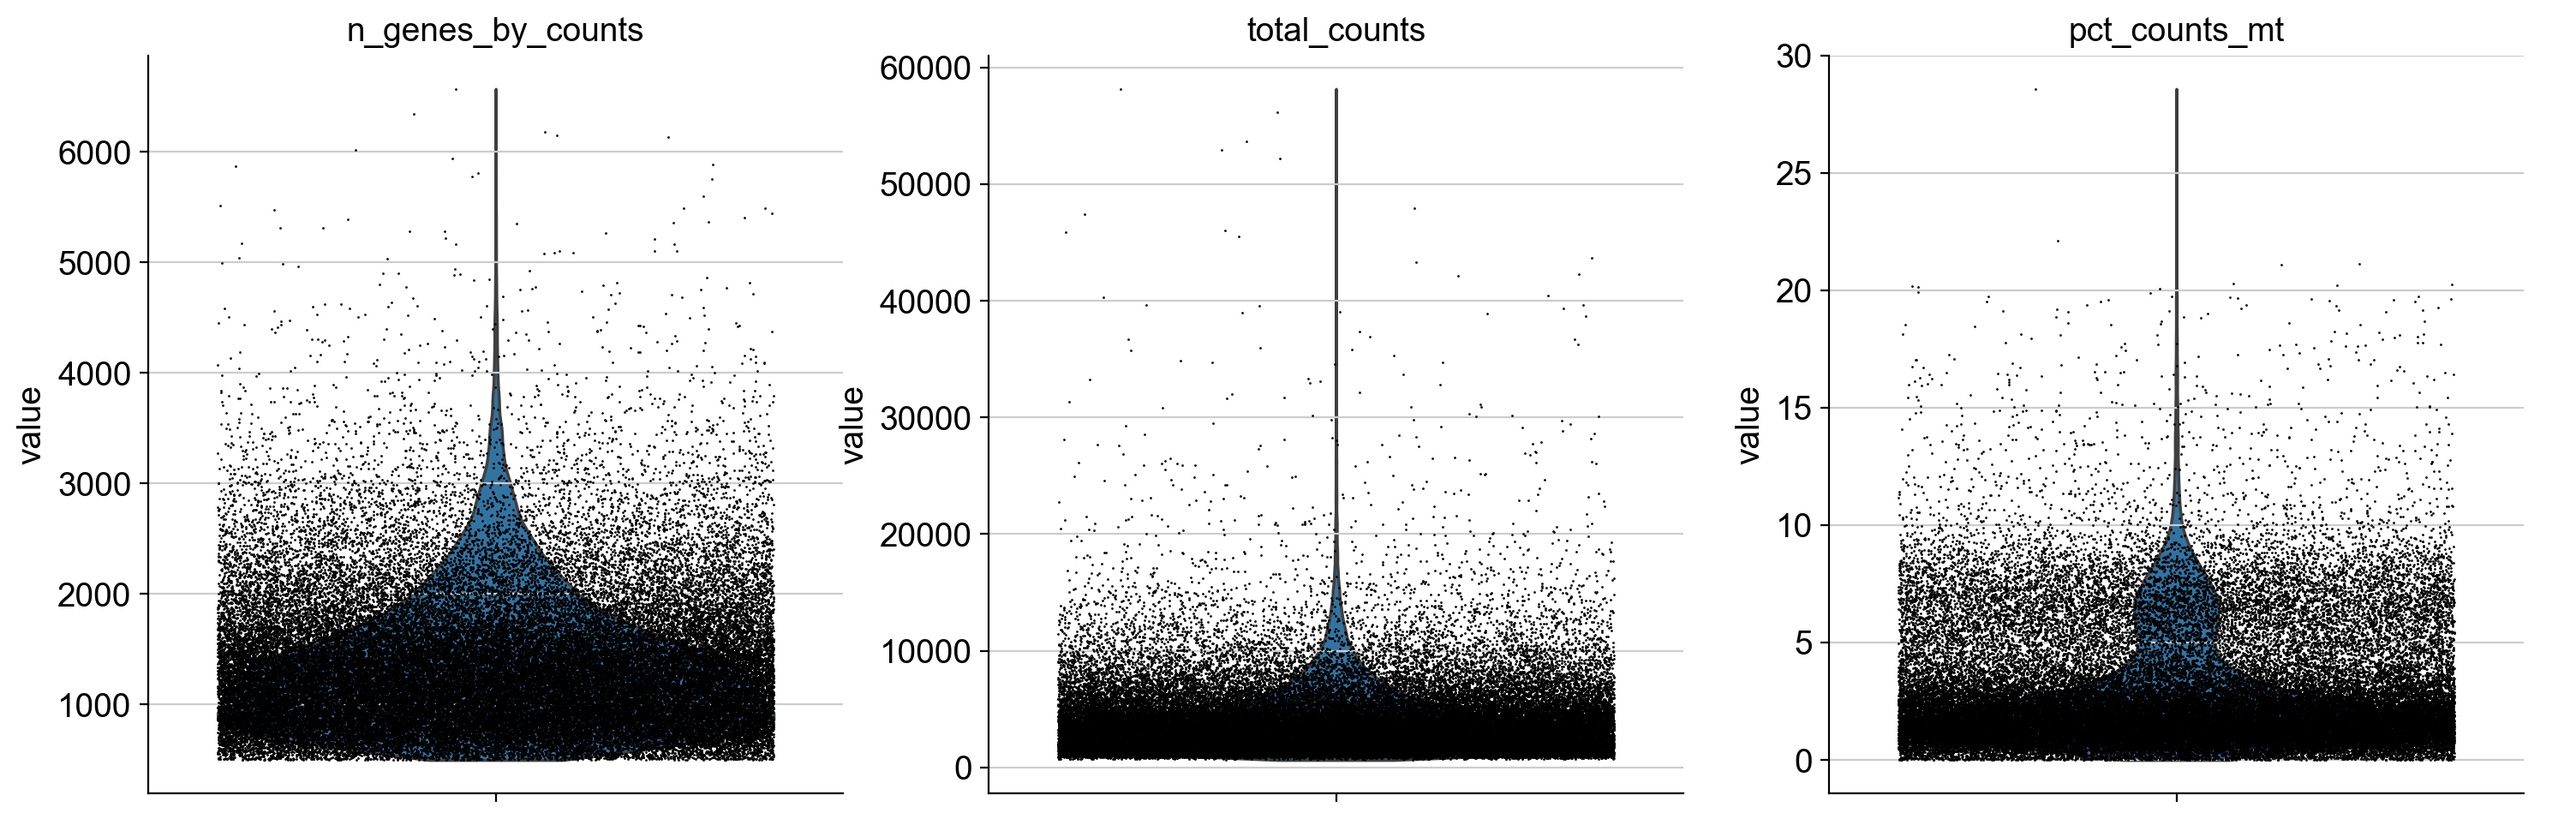

In [10]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

In [11]:
#Filtering out rare genes
print("Before QC:", adata.shape)

sc.pp.filter_cells(
    adata,
    min_genes=200,
)

sc.pp.filter_genes(
    adata,
    min_cells=3,
)

adata = adata[
    adata.obs["pct_counts_mt"] < 20
].copy()

print("After QC:", adata.shape)

Before QC: (59506, 61497)
filtered out 40608 genes that are detected in less than 3 cells
After QC: (59496, 20889)


In [12]:
celltype_counts = adata.obs["cell_type"].value_counts()

donor_support = (
    adata.obs
    .groupby("cell_type", observed=True)["donor_id"]
    .nunique()
)

celltype_summary = pd.DataFrame({
    "n_cells": celltype_counts,
    "n_donors": donor_support,
}).sort_values("n_cells", ascending=False)

celltype_summary.head(30)

,n_cells,n_donors
cell_type,,
monocyte,29872,15
"CD8-positive, alpha-beta T cell",8655,15
"CD4-positive, alpha-beta T cell",6725,15
B cell,6131,15
natural killer cell,3248,15
alpha-beta T cell,1659,15
dendritic cell,1038,15
platelet,1007,14
plasmablast,586,15


In [13]:
MIN_CELLS_PER_TYPE = 300
MIN_DONORS_PER_TYPE = 3
TOP_N_CELL_TYPES = 8

eligible = celltype_summary[
    (celltype_summary["n_cells"] >= MIN_CELLS_PER_TYPE)
    &
    (celltype_summary["n_donors"] >= MIN_DONORS_PER_TYPE)
]

selected_celltypes = (
    eligible
    .head(TOP_N_CELL_TYPES)
    .index
    .tolist()
)

print("Selected cell types:")
for ct in selected_celltypes:
    print(
        ct,
        "| cells =", celltype_summary.loc[ct, "n_cells"],
        "| donors =", celltype_summary.loc[ct, "n_donors"],
    )

Selected cell types:
monocyte | cells = 29872 | donors = 15
CD8-positive, alpha-beta T cell | cells = 8655 | donors = 15
CD4-positive, alpha-beta T cell | cells = 6725 | donors = 15
B cell | cells = 6131 | donors = 15
natural killer cell | cells = 3248 | donors = 15
alpha-beta T cell | cells = 1659 | donors = 15
dendritic cell | cells = 1038 | donors = 15
platelet | cells = 1007 | donors = 14


In [14]:
adata = adata[
    adata.obs["cell_type"].isin(selected_celltypes)
].copy()

adata.obs["cell_type"] = pd.Categorical(
    adata.obs["cell_type"],
    categories=selected_celltypes,
)

print(adata)

AnnData object with n_obs × n_vars = 58335 × 20889
    obs: 'dataset_id', 'donor_id', 'cell_type', 'disease', 'assay', 'tissue', 'tissue_general', 'is_primary_data', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'feature_id', 'feature_name', 'gene_name', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'


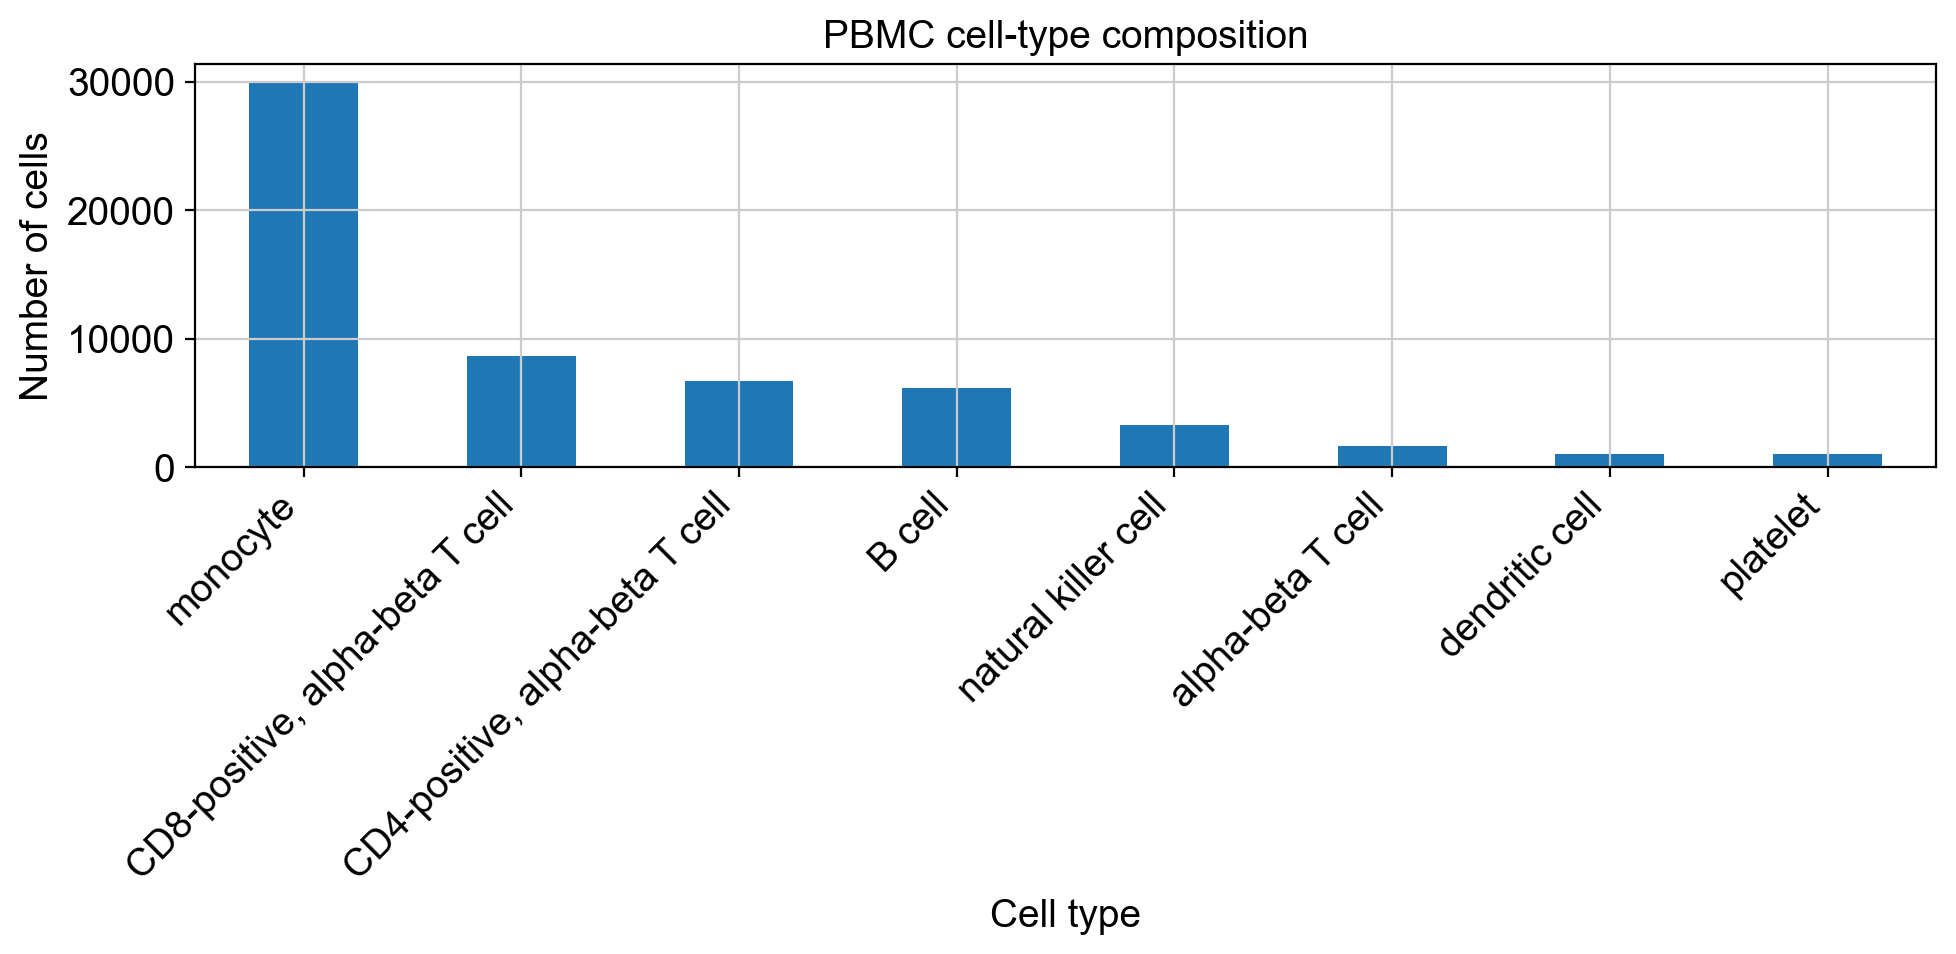

In [15]:
#Plot cell-type composition
counts = (
    adata.obs["cell_type"]
    .value_counts()
    .sort_values(ascending=False)
)

ax = counts.plot(
    kind="bar",
    figsize=(10, 5),
)

ax.set_ylabel("Number of cells")
ax.set_xlabel("Cell type")
ax.set_title("PBMC cell-type composition")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "celltype_counts.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

In [16]:
donor_celltype_table = pd.crosstab(
    adata.obs["donor_id"],
    adata.obs["cell_type"],
)

donor_celltype_table


cell_type,monocyte,"CD8-positive, alpha-beta T cell","CD4-positive, alpha-beta T cell",B cell,natural killer cell,alpha-beta T cell,dendritic cell,platelet
donor_id,,,,,,,,
3,1412,1883,352,289,189,185,40,50
90,3879,845,911,760,1018,249,201,71
144,592,245,805,247,165,124,39,46
161,825,392,138,110,119,44,12,47
180,245,44,18,29,12,6,8,14
184,5192,1421,565,459,397,219,156,194
218,2888,255,333,826,142,66,144,267
219,1408,73,103,224,45,34,44,6
259,1362,346,462,591,92,93,26,38


In [17]:
def make_donor_split(
    adata,
    donor_col="donor_id",
    label_col="cell_type",
    test_fraction=0.20,
    val_fraction=0.15,
    seed=42,
    max_attempts=1000,
):
    donors = np.array(
        sorted(adata.obs[donor_col].unique())
    )

    if len(donors) < 5:
        raise ValueError(
            f"Only {len(donors)} donors available. "
            "Need at least ~5 for a useful donor split."
        )

    all_labels = set(
        adata.obs[label_col].astype(str).unique()
    )

    n_test = max(
        1,
        int(round(len(donors) * test_fraction))
    )

    n_val = max(
        1,
        int(round(len(donors) * val_fraction))
    )

    # Make sure at least one training donor remains
    while n_test + n_val >= len(donors):
        if n_val > 1:
            n_val -= 1
        elif n_test > 1:
            n_test -= 1
        else:
            raise ValueError("Not enough donors.")

    for attempt in range(max_attempts):

        rng = np.random.default_rng(seed + attempt)

        shuffled = rng.permutation(donors)

        test_donors = set(shuffled[:n_test])

        val_donors = set(
            shuffled[n_test:n_test + n_val]
        )

        train_donors = set(
            shuffled[n_test + n_val:]
        )

        train_mask = adata.obs[donor_col].isin(train_donors)
        val_mask = adata.obs[donor_col].isin(val_donors)
        test_mask = adata.obs[donor_col].isin(test_donors)

        train_labels = set(
            adata.obs.loc[
                train_mask,
                label_col,
            ].astype(str)
        )

        val_labels = set(
            adata.obs.loc[
                val_mask,
                label_col,
            ].astype(str)
        )

        test_labels = set(
            adata.obs.loc[
                test_mask,
                label_col,
            ].astype(str)
        )

        # Training set must contain every class we may encounter
        if (
            val_labels.issubset(train_labels)
            and
            test_labels.issubset(train_labels)
            and
            all_labels.issubset(train_labels)
        ):
            return {
                "train": train_donors,
                "val": val_donors,
                "test": test_donors,
            }

    raise RuntimeError(
        "Could not find a donor split with adequate "
        "cell-type coverage. Try reducing TOP_N_CELL_TYPES."
    )

In [18]:
donor_split = make_donor_split(
    adata,
    seed=SEED,
)

for split, donors in donor_split.items():
    print(f"\n{split.upper()}")
    print(sorted(donors))


TRAIN
[np.str_('161'), np.str_('180'), np.str_('218'), np.str_('219'), np.str_('318'), np.str_('345'), np.str_('366'), np.str_('367'), np.str_('370'), np.str_('90')]

VAL
[np.str_('144'), np.str_('184')]

TEST
[np.str_('259'), np.str_('3'), np.str_('336')]


In [19]:
adata.obs["split"] = "unassigned"

for split_name, donors in donor_split.items():
    mask = adata.obs["donor_id"].isin(donors)
    adata.obs.loc[mask, "split"] = split_name

adata.obs["split"].value_counts()

split
train    32252
test     15217
val      10866
Name: count, dtype: int64

In [20]:
#Leakage check for the data

train_donors = set(
    adata.obs.loc[
        adata.obs["split"] == "train",
        "donor_id",
    ]
)

val_donors = set(
    adata.obs.loc[
        adata.obs["split"] == "val",
        "donor_id",
    ]
)

test_donors = set(
    adata.obs.loc[
        adata.obs["split"] == "test",
        "donor_id",
    ]
)

assert train_donors.isdisjoint(val_donors)
assert train_donors.isdisjoint(test_donors)
assert val_donors.isdisjoint(test_donors)

print("No donor leakage.")

No donor leakage.


In [21]:
#Creating the 3 datasets
adata_train = adata[
    adata.obs["split"] == "train"
].copy()

adata_val = adata[
    adata.obs["split"] == "val"
].copy()

adata_test = adata[
    adata.obs["split"] == "test"
].copy()

print("Train:", adata_train.shape)
print("Val:  ", adata_val.shape)
print("Test: ", adata_test.shape)

Train: (32252, 20889)
Val:   (10866, 20889)
Test:  (15217, 20889)


In [22]:
#Saving the raw splits
adata_train.write_h5ad(
    DATA_DIR / "train_raw.h5ad"
)

adata_val.write_h5ad(
    DATA_DIR / "val_raw.h5ad"
)

adata_test.write_h5ad(
    DATA_DIR / "test_raw.h5ad"
)

print("Saved raw train/val/test datasets.")

Saved raw train/val/test datasets.


In [23]:
#Normalizing the datasets
train_base = adata_train.copy()
val_base = adata_val.copy()
test_base = adata_test.copy()

def normalize_log1p(adata):
    sc.pp.normalize_total(
        adata,
        target_sum=1e4,
    )

    sc.pp.log1p(adata)

    return adata


normalize_log1p(train_base)
normalize_log1p(val_base)
normalize_log1p(test_base)

normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)


AnnData object with n_obs × n_vars = 15217 × 20889
    obs: 'dataset_id', 'donor_id', 'cell_type', 'disease', 'assay', 'tissue', 'tissue_general', 'is_primary_data', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'split'
    var: 'feature_id', 'feature_name', 'gene_name', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'log1p'

In [24]:
#Find top 2000 HVG using training data
sc.pp.highly_variable_genes(
    train_base,
    n_top_genes=2000,
    flavor="seurat",
)

print(
    train_base.var["highly_variable"].value_counts()
)

extracting highly variable genes
    finished (0:00:00)
highly_variable
False    18889
True      2000
Name: count, dtype: int64


In [25]:
#Store HVG
hvg_ids = train_base.var_names[
    train_base.var["highly_variable"]
].tolist()

train_base = train_base[:, hvg_ids].copy()
val_base = val_base[:, hvg_ids].copy()
test_base = test_base[:, hvg_ids].copy()

print(train_base.shape)
print(val_base.shape)
print(test_base.shape)

(32252, 2000)
(10866, 2000)
(15217, 2000)


In [26]:
#save as file 
with open(
    RESULTS_DIR / "baseline_hvg_ids.json",
    "w",
) as f:
    json.dump(hvg_ids, f)

In [27]:
#Prep X and Y for train, val, and split
X_train = train_base.X
X_val = val_base.X
X_test = test_base.X

y_train = train_base.obs["cell_type"].astype(str).values
y_val = val_base.obs["cell_type"].astype(str).values
y_test = test_base.obs["cell_type"].astype(str).values

In [28]:
baseline = Pipeline([
    #svd for dimensionality
    (
        "svd",
        TruncatedSVD(
            n_components=50,
            random_state=SEED,
        ),
    ),
    #standardization
    (
        "scale",
        StandardScaler(),
    ),
    #LR
    (
        "classifier",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=SEED,
        ),
    ),
])

In [29]:
#Training
baseline.fit(
    X_train,
    y_train,
)

print("Baseline trained.")

Baseline trained.


/Users/skamano/miniconda3/envs/scgpt-project/lib/python3.10/site-packages/sklearn/utils/extmath.py:590: RuntimeWarning: divide by zero encountered in matmul
  U = Q @ Uhat
/Users/skamano/miniconda3/envs/scgpt-project/lib/python3.10/site-packages/sklearn/utils/extmath.py:590: RuntimeWarning: overflow encountered in matmul
  U = Q @ Uhat
/Users/skamano/miniconda3/envs/scgpt-project/lib/python3.10/site-packages/sklearn/utils/extmath.py:590: RuntimeWarning: invalid value encountered in matmul
  U = Q @ Uhat
/Users/skamano/miniconda3/envs/scgpt-project/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/skamano/miniconda3/envs/scgpt-project/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/User

In [30]:
#Validation Performance
val_pred = baseline.predict(X_val)

val_metrics = {
    "accuracy": accuracy_score(
        y_val,
        val_pred,
    ),
    "balanced_accuracy": balanced_accuracy_score(
        y_val,
        val_pred,
    ),
    "macro_f1": f1_score(
        y_val,
        val_pred,
        average="macro",
    ),
    "weighted_f1": f1_score(
        y_val,
        val_pred,
        average="weighted",
    ),
}

val_metrics

/Users/skamano/miniconda3/envs/scgpt-project/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/skamano/miniconda3/envs/scgpt-project/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/skamano/miniconda3/envs/scgpt-project/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


{'accuracy': 0.6733848702374379,
 'balanced_accuracy': 0.6644253221377955,
 'macro_f1': 0.5767636145909462,
 'weighted_f1': 0.7320868587573879}

In [31]:
print(
    classification_report(
        y_val,
        val_pred,
        zero_division=0,
    )
)

                                 precision    recall  f1-score   support

                         B cell       0.75      0.62      0.68       706
CD4-positive, alpha-beta T cell       0.89      0.82      0.85      1370
CD8-positive, alpha-beta T cell       0.80      0.70      0.74      1666
              alpha-beta T cell       0.34      0.63      0.44       343
                 dendritic cell       0.20      0.56      0.29       195
                       monocyte       0.95      0.64      0.77      5784
            natural killer cell       0.68      0.71      0.69       562
                       platelet       0.08      0.63      0.14       240

                       accuracy                           0.67     10866
                      macro avg       0.59      0.66      0.58     10866
                   weighted avg       0.84      0.67      0.73     10866



In [32]:
#Test metrics
test_pred = baseline.predict(X_test)

test_metrics = {
    "accuracy": accuracy_score(
        y_test,
        test_pred,
    ),
    "balanced_accuracy": balanced_accuracy_score(
        y_test,
        test_pred,
    ),
    "macro_f1": f1_score(
        y_test,
        test_pred,
        average="macro",
    ),
    "weighted_f1": f1_score(
        y_test,
        test_pred,
        average="weighted",
    ),
}

test_metrics

/Users/skamano/miniconda3/envs/scgpt-project/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/skamano/miniconda3/envs/scgpt-project/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/skamano/miniconda3/envs/scgpt-project/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


{'accuracy': 0.8600906880462641,
 'balanced_accuracy': 0.8264485999067064,
 'macro_f1': 0.7070064666291715,
 'weighted_f1': 0.8779777792232266}

In [33]:
print("LOGISTIC REGRESSION BASELINE")
print("=" * 40)

for metric, value in test_metrics.items():
    print(f"{metric:20s}: {value:.4f}")

LOGISTIC REGRESSION BASELINE
accuracy            : 0.8601
balanced_accuracy   : 0.8264
macro_f1            : 0.7070
weighted_f1         : 0.8780


In [34]:
#Report
report = classification_report(
    y_test,
    test_pred,
    output_dict=True,
    zero_division=0,
)

report_df = pd.DataFrame(report).T

report_df

,precision,recall,f1-score,support
B cell,0.927635,0.938960,0.933263,1884.000000
"CD4-positive, alpha-beta T cell",0.868174,0.874931,0.871539,1799.000000
"CD8-positive, alpha-beta T cell",0.926534,0.863410,0.893859,3009.000000
alpha-beta T cell,0.431373,0.705128,0.535280,468.000000
dendritic cell,0.439583,0.897872,0.590210,235.000000
monocyte,0.982822,0.846670,0.909680,7298.000000
natural killer cell,0.608547,0.872549,0.717019,408.000000
platelet,0.123264,0.612069,0.205202,116.000000
accuracy,0.860091,0.860091,0.860091,0.860091
macro avg,0.663491,0.826449,0.707006,15217.000000


In [35]:
#Save report
report_df.to_csv(
    RESULTS_DIR /
    "baseline_classification_report.csv"
)

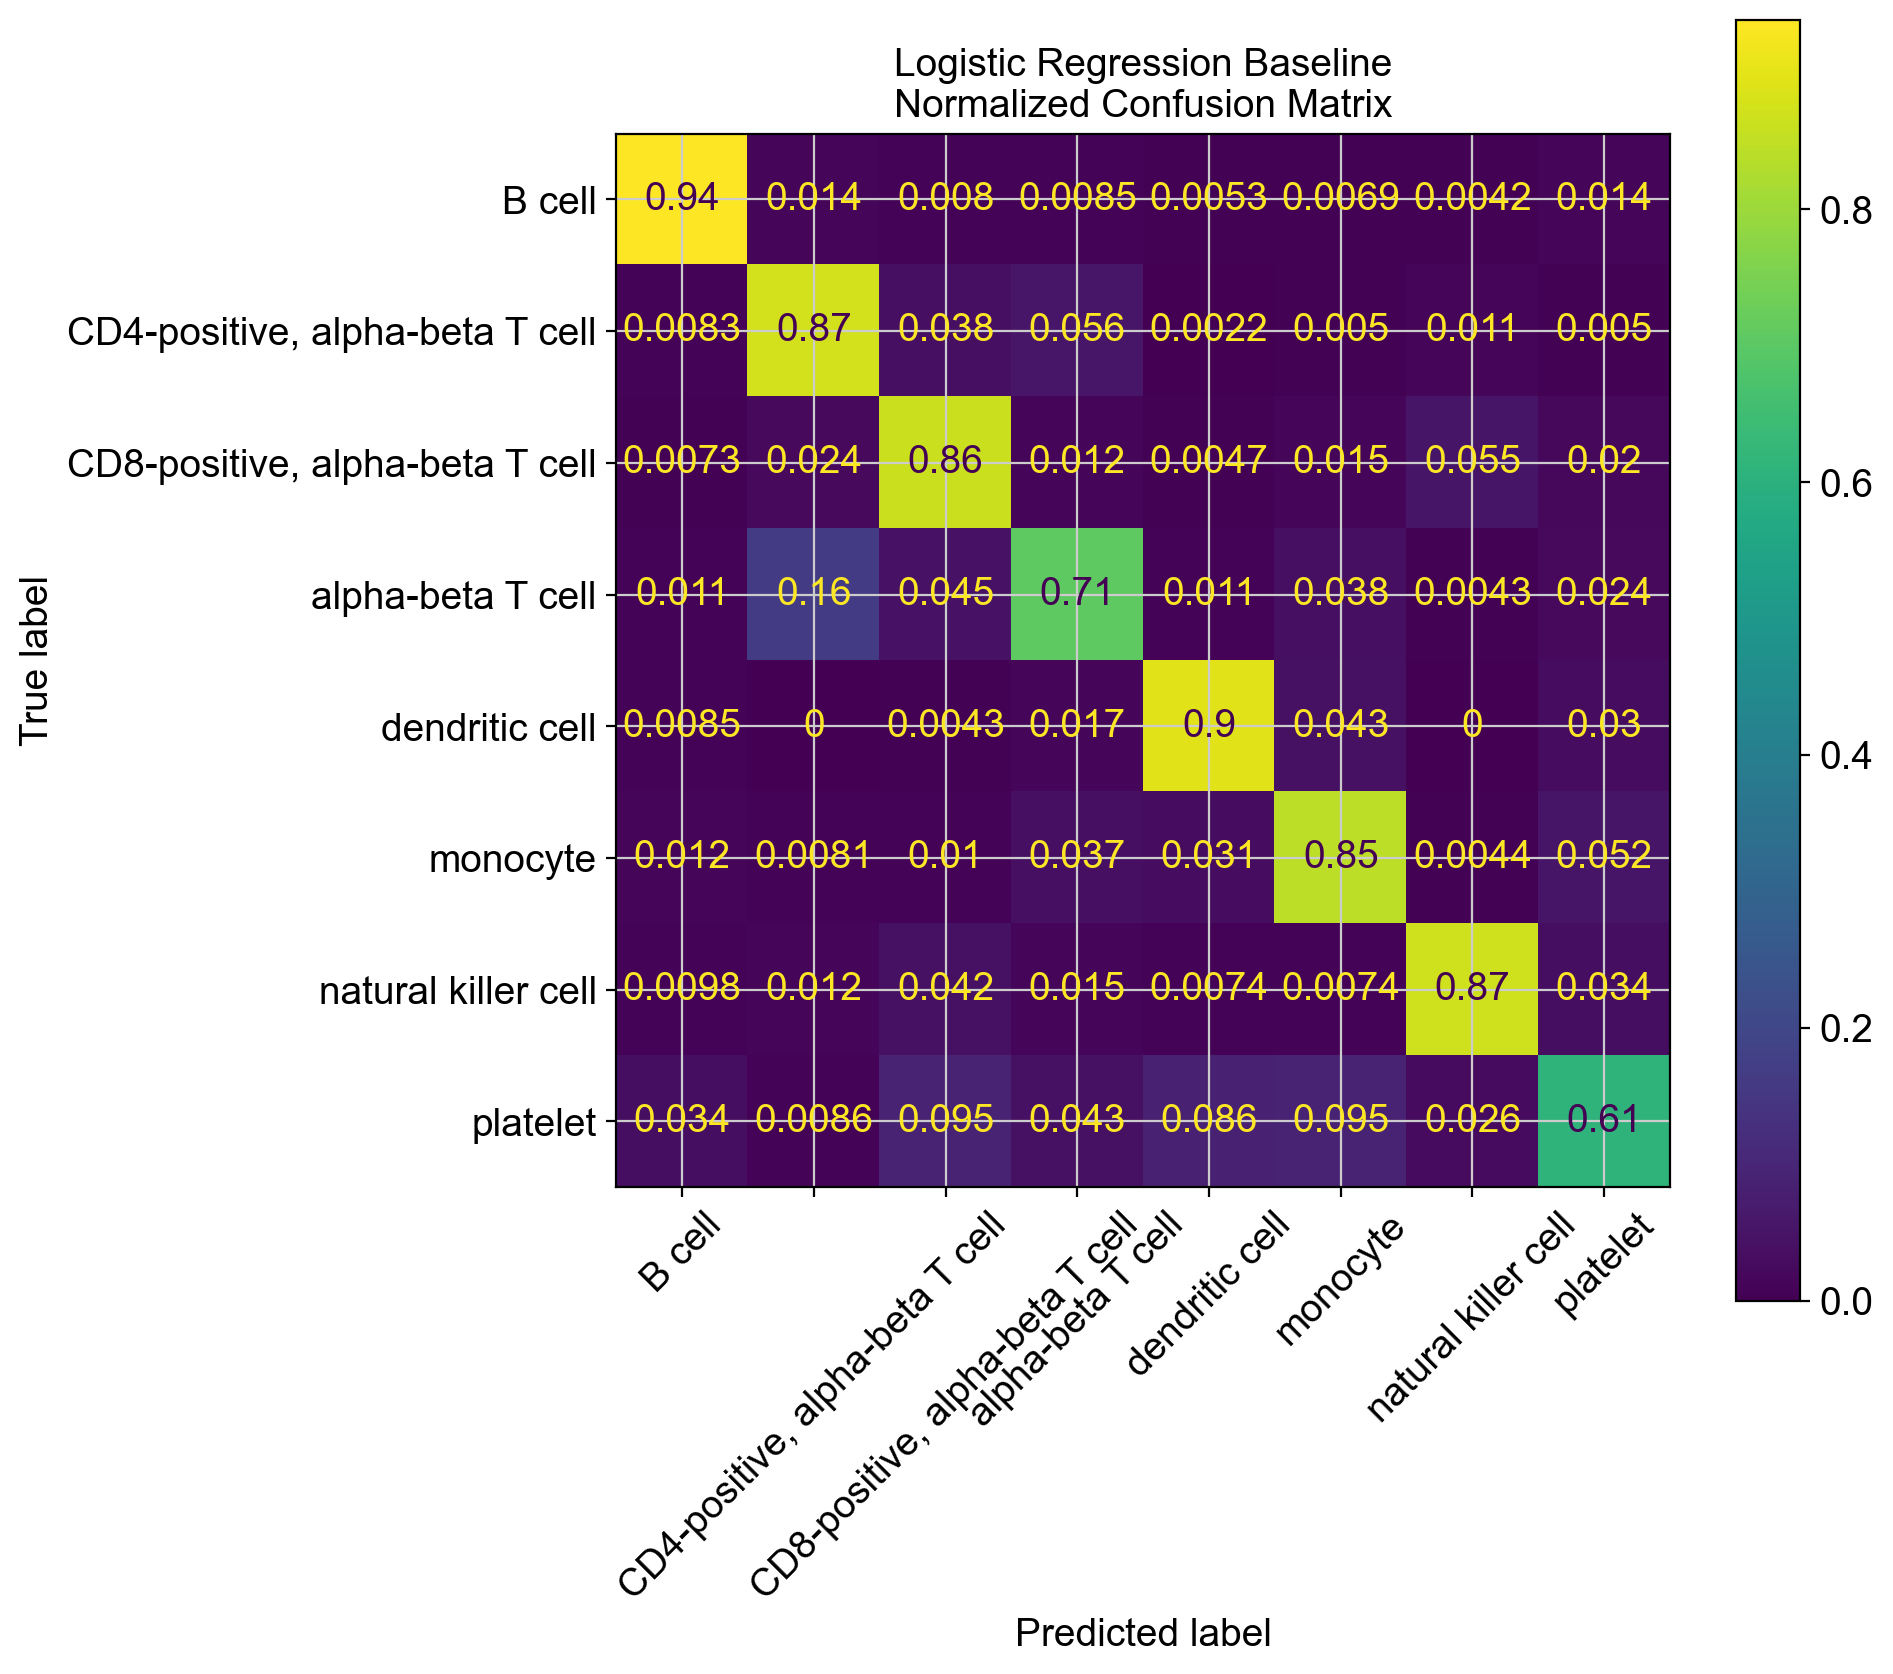

In [36]:
#Confusion Matrix
fig, ax = plt.subplots(
    figsize=(10, 9)
)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_pred,
    normalize="true",
    xticks_rotation=45,
    ax=ax,
)

ax.set_title(
    "Logistic Regression Baseline\n"
    "Normalized Confusion Matrix"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "baseline_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [37]:
#Save the baseline
joblib.dump(
    baseline,
    RESULTS_DIR / "baseline_model.joblib",
)

print("Model saved.")

metrics_df = pd.DataFrame([
    {
        "model": "HVG_SVD_LogisticRegression",
        "split": "validation",
        **val_metrics,
    },
    {
        "model": "HVG_SVD_LogisticRegression",
        "split": "test",
        **test_metrics,
    },
])

metrics_df.to_csv(
    RESULTS_DIR /
    "baseline_metrics.csv",
    index=False,
)

Model saved.
